# Exam Score Prediction using Linear Regression
### Attendance Rate, Study Hours & Internet Access → Final Score Prediction

In [53]:
import numpy as np
import pandas as pd 

## Load Dataset

In [54]:
df = pd.read_csv('student_performance.csv')
df.head()

,student_id,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed
0,STU0001,Male,15,25,63.8,Bachelor,Yes,Yes,41,67,Yes
1,STU0002,Female,15,2,54.7,Bachelor,Yes,Yes,83,28,No
2,STU0003,Female,19,10,90.5,High School,Yes,No,73,49,No
3,STU0004,Male,16,26,66.8,High School,No,Yes,75,70,Yes
4,STU0005,Female,15,25,73.0,High School,No,Yes,67,77,Yes


## Basic Inspection

In [55]:
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            500 non-null    str    
 1   gender                500 non-null    str    
 2   age                   500 non-null    int64  
 3   study_hours_per_week  500 non-null    int64  
 4   attendance_rate       500 non-null    float64
 5   parent_education      383 non-null    str    
 6   internet_access       500 non-null    str    
 7   extracurricular       500 non-null    str    
 8   previous_score        500 non-null    int64  
 9   final_score           500 non-null    int64  
 10  passed                500 non-null    str    
dtypes: float64(1), int64(4), str(6)
memory usage: 43.1 KB


## Check Null Values

In [56]:
df.columns[df.isna().any()]

Index(['parent_education'], dtype='str')

In [57]:
df.duplicated().sum()

np.int64(0)

## Segregate Dataset into X (input) and Y (output)

In [58]:
df['internet_access'] = df['internet_access'].map({'Yes': 1, 'No': 0})
x = df[['attendance_rate', 'study_hours_per_week', 'internet_access']] 
x.head()

,attendance_rate,study_hours_per_week,internet_access
0,63.8,25,1
1,54.7,2,1
2,90.5,10,1
3,66.8,26,0
4,73.0,25,0


In [59]:
y = df['final_score']
y.head()

0    67
1    28
2    49
3    70
4    77
Name: final_score, dtype: int64

## Train Test Spliting

In [60]:
from sklearn.model_selection import train_test_split
x_Train, x_Test, y_Train, y_Test = train_test_split(x, y, test_size =  0.2, random_state = 42)

## Model Train

In [61]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_Train, y_Train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[0.27,1.45,0.23]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['attendance_rate','study_hours_per_week','internet_access']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,12.77
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [65]:
print("Intercept (b0): ",model.intercept_)
print("Coefficients (b1, b2, b3): ",model.coef_)
a = pd.DataFrame([[100, 30, 1]], columns=['attendance_rate', 'study_hours_per_week', 'internet_access'])
PredictedmodelResult = model.predict(a)
print(PredictedmodelResult)

Intercept (b0):  12.769238094406148
Coefficients (b1, b2, b3):  [0.27213288 1.44685749 0.23072584]
[83.61897617]


## Evaluation

In [68]:
y_pred = model.predict(x_Test)
from sklearn.metrics import r2_score

r2 = r2_score(y_Test, y_pred)
print("R^2 Score: ", r2)

R^2 Score:  0.69254936209671


## Visualization

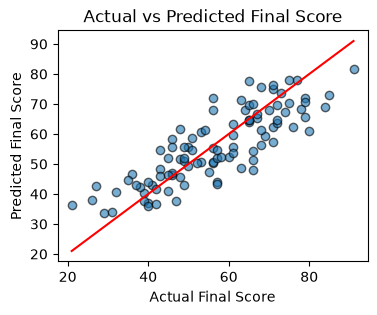

In [77]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 3))
plt.scatter(y_Test, y_pred, alpha=0.6, edgecolors='k')
plt.plot([y_Test.min(), y_Test.max()], [y_Test.min(), y_Test.max()], 'r-')  # perfect prediction line
plt.xlabel('Actual Final Score')
plt.ylabel('Predicted Final Score')
plt.title('Actual vs Predicted Final Score')
plt.show()

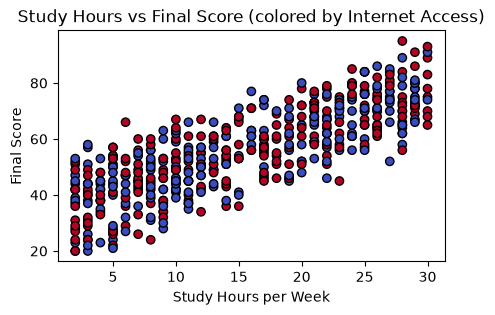

In [84]:
plt.figure(figsize=(5, 3))
plt.scatter(df['study_hours_per_week'], df['final_score'], c=df['internet_access'], cmap='coolwarm', edgecolors='k')
plt.xlabel('Study Hours per Week')
plt.ylabel('Final Score')
plt.title('Study Hours vs Final Score (colored by Internet Access)')
plt.show()

## Correlation Heatmap

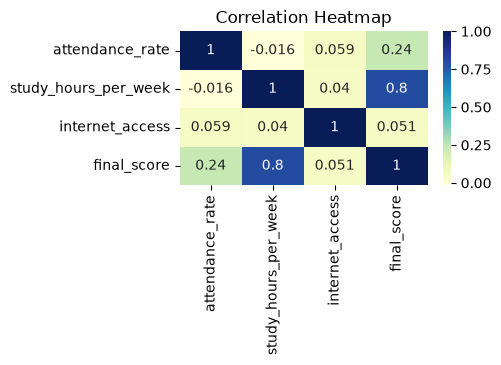

In [90]:
import seaborn as sns

plt.figure(figsize=(4, 2))
sns.heatmap(df[['attendance_rate', 'study_hours_per_week', 'internet_access', 'final_score']].corr(), annot=True, cmap='YlGnBu')
plt.title('Correlation Heatmap')
plt.show()